In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/yzta-2026-datathon/sample_submission.csv
/kaggle/input/competitions/yzta-2026-datathon/test_x.csv
/kaggle/input/competitions/yzta-2026-datathon/train.csv


In [2]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('yzta-2026-datathon')

print("Path to competition files:", path)


Path to competition files: /kaggle/input/competitions/yzta-2026-datathon


In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/yzta-2026-datathon/sample_submission.csv
/kaggle/input/competitions/yzta-2026-datathon/test_x.csv
/kaggle/input/competitions/yzta-2026-datathon/train.csv


In [4]:
import pandas as pd

# Bilgisayarın bize söylediği tam adresleri kullanıyoruz:
train = pd.read_csv('/kaggle/input/competitions/yzta-2026-datathon/train.csv')
test = pd.read_csv('/kaggle/input/competitions/yzta-2026-datathon/test_x.csv')

print("Dosyalar başarıyla okundu! Veri seti boyutu:", train.shape)

Dosyalar başarıyla okundu! Veri seti boyutu: (56000, 24)


bilissel_performans_skoru      1.000000
rem_yuzdesi                    0.442999
derin_uyku_yuzdesi             0.280006
gunluk_adim_sayisi             0.134042
hafta_sonu_uyku_farki_saat    -0.001648
id                            -0.005845
oda_sicakligi_celsius         -0.011992
sekerleme_suresi_dk           -0.023683
vucut_kitle_indeksi           -0.037990
uyku_oncesi_ekran_suresi_dk   -0.044631
uyku_oncesi_kafein_mg         -0.062387
yas                           -0.070659
dinlenik_nabiz_bpm            -0.089389
uykuya_dalma_suresi_dk        -0.207349
gecelik_uyanma_sayisi         -0.270349
gunluk_calisma_saati          -0.342112
stres_skoru                   -0.586676
Name: bilissel_performans_skoru, dtype: float64


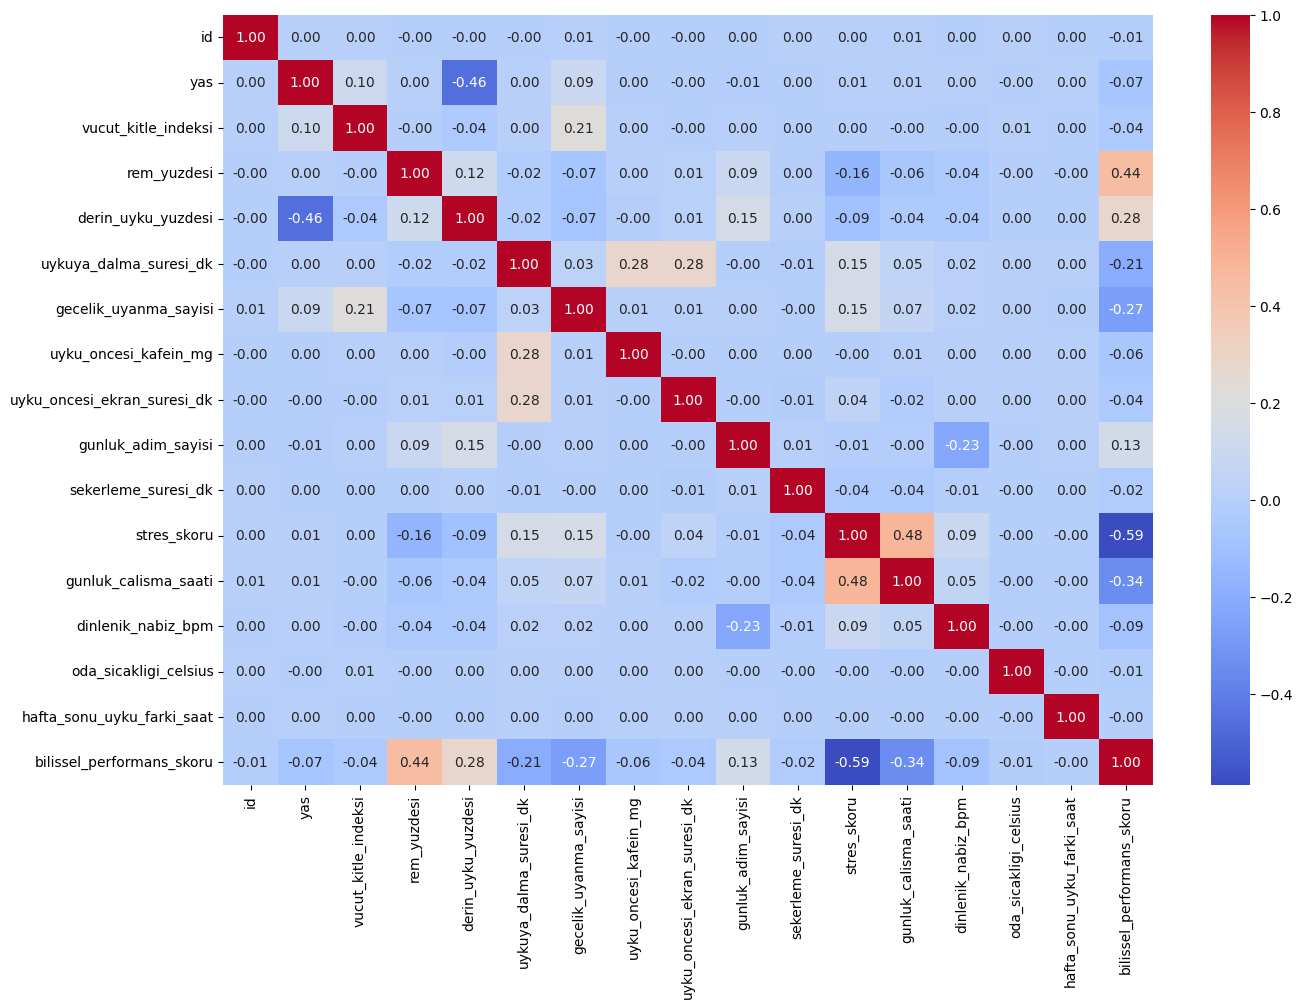

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sayisal_veriler = train.select_dtypes(include=['number'])
korelasyon = sayisal_veriler.corr()

print(korelasyon["bilissel_performans_skoru"].sort_values(ascending=False))

plt.figure(figsize=(15, 10))
sns.heatmap(korelasyon, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

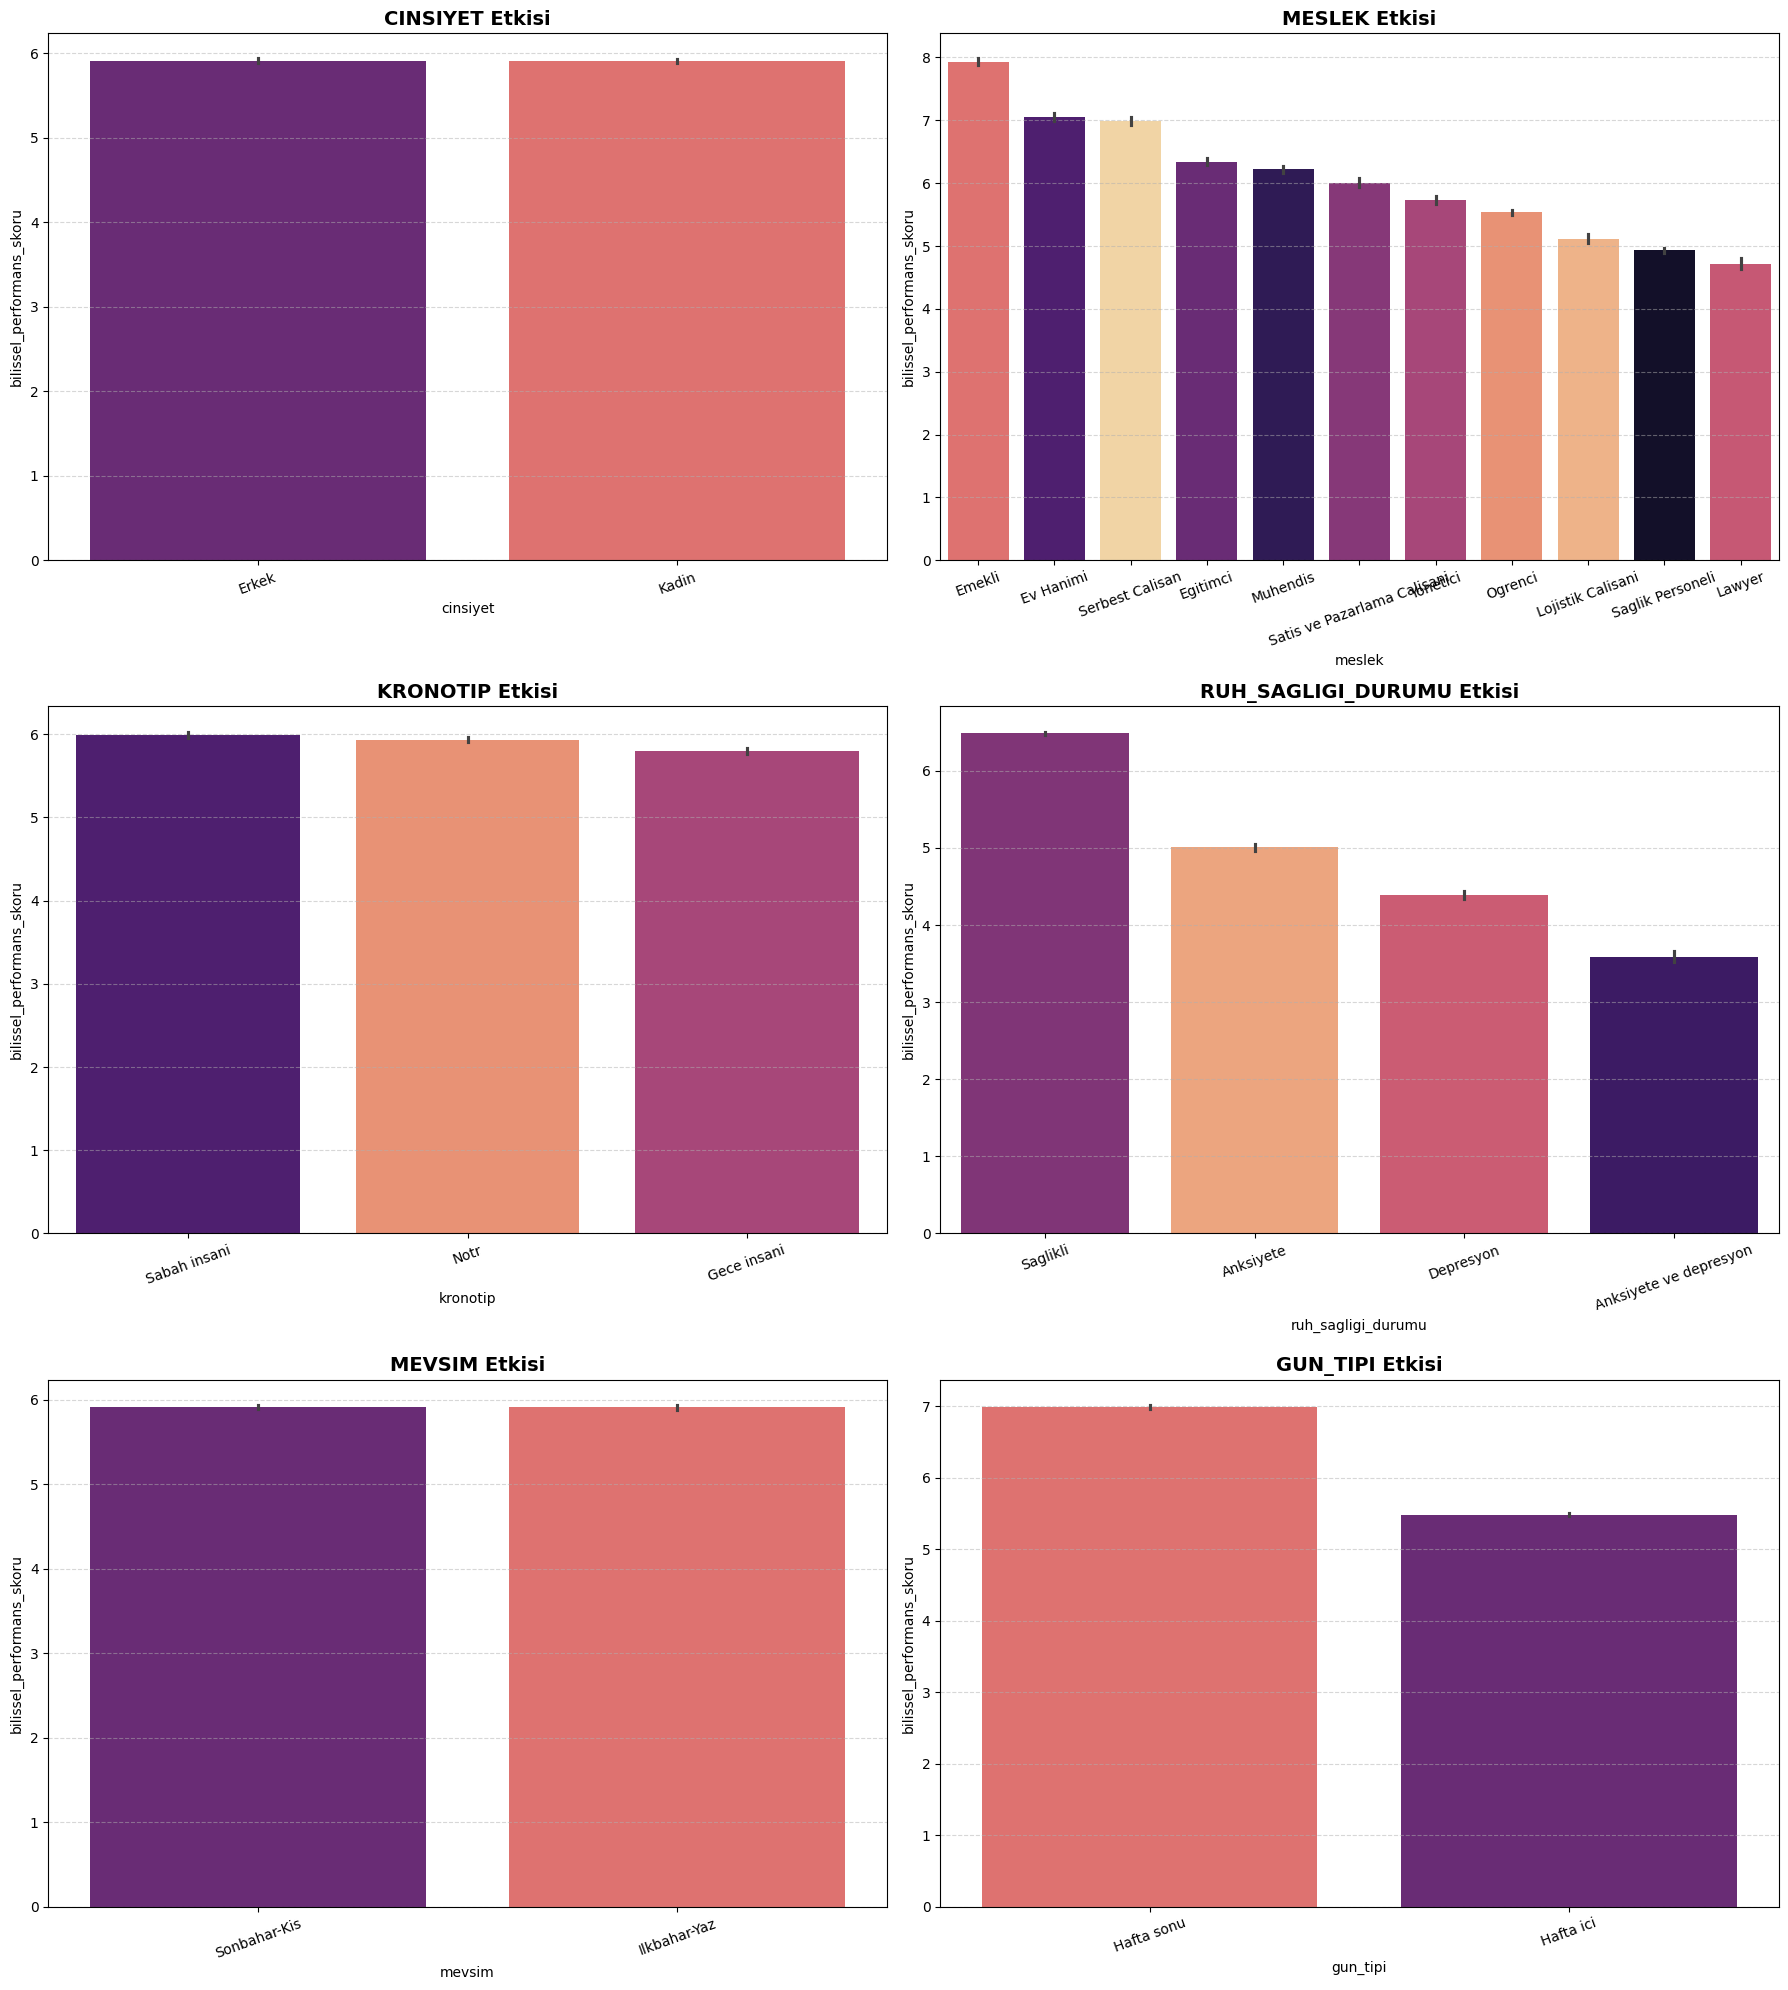

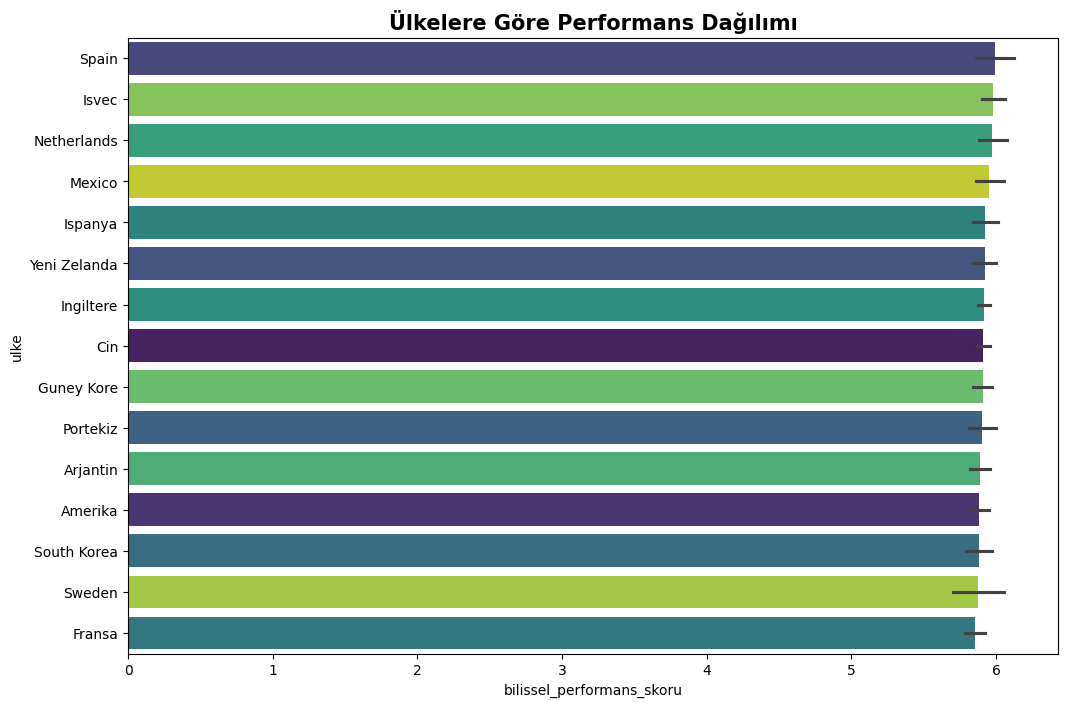

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Veriyi yükle
train = pd.read_csv('/kaggle/input/competitions/yzta-2026-datathon/train.csv')

# TÜM kategorik değişkenlerin listesi
tum_kategorikler = ['cinsiyet', 'meslek', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']

# Görselleştirme (2 sütunlu düzen)
plt.figure(figsize=(18, 20))

for i, sutun in enumerate(tum_kategorikler, 1):
    plt.subplot(3, 2, i)
    
    # Ortalama skora göre sırala
    siralama = train.groupby(sutun)['bilissel_performans_skoru'].mean().sort_values(ascending=False).index
    
    sns.barplot(data=train, x=sutun, y='bilissel_performans_skoru', 
                order=siralama, palette='magma', hue=sutun, legend=False)
    
    plt.title(f'{sutun.upper()} Etkisi', fontsize=14, fontweight='bold')
    plt.xticks(rotation=20)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Ülke değişkenini çok kalabalık olduğu için yine tek başına büyük çiziyoruz
plt.figure(figsize=(12, 8))
ulke_siralama = train.groupby('ulke')['bilissel_performans_skoru'].mean().sort_values(ascending=False).index
sns.barplot(data=train, x='bilissel_performans_skoru', y='ulke', order=ulke_siralama, palette='viridis', hue='ulke', legend=False)
plt.title('Ülkelere Göre Performans Dağılımı', fontsize=15, fontweight='bold')
plt.show()

In [7]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from scipy.stats.mstats import winsorize

# 1. VERİYİ YÜKLEME
train = pd.read_csv('/kaggle/input/competitions/yzta-2026-datathon/train.csv')
test = pd.read_csv('/kaggle/input/competitions/yzta-2026-datathon/test_x.csv')

# --- ADIM 1: ÖN TEMİZLİK (Dil ve Yazım Birliği) ---
def clean_categories(df):
    mapping = {
        'Lawyer': 'Avukat', 'Engineer': 'Muhendis', 'Doctor': 'Doktor',
        'Student': 'Ogrenci', 'Teacher': 'Ogretmen'
    }
    df['meslek'] = df['meslek'].replace(mapping)
    # Varsa tüm metinleri standartlaştırmak için (küçük harf vb.) eklenebilir
    return df

train = clean_categories(train)
test = clean_categories(test)

# --- ADIM 2: EKSİK DEĞER YÖNETİMİ (Imputation) ---
# Sayısal: Median, Kategorik: Mode
sayisal_cols = ['vucut_kitle_indeksi', 'stres_skoru', 'uyku_oncesi_kafein_mg']
kat_cols = ['meslek', 'kronotip', 'ruh_sagligi_durumu']

num_imputer = SimpleImputer(strategy='median')
train[sayisal_cols] = num_imputer.fit_transform(train[sayisal_cols])
test[sayisal_cols] = num_imputer.transform(test[sayisal_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
train[kat_cols] = cat_imputer.fit_transform(train[kat_cols])
test[kat_cols] = cat_imputer.transform(test[kat_cols])

# --- ADIM 3: AYKIRI DEĞER ANALİZİ (Winsorization) ---
outlier_cols = ['gunluk_adim_sayisi', 'uykuya_dalma_suresi_dk', 'sekerleme_suresi_dk']
for col in outlier_cols:
    train[col] = winsorize(train[col], limits=[0.01, 0.01])
    test[col] = winsorize(test[col], limits=[0.01, 0.01])

# --- ADIM 4: KATEGORİK DEĞİŞKEN DÖNÜŞTÜRME (Encoding) ---

# A. Binary Encoding (2 Sınıflı: Label Encoding)
le = LabelEncoder()
for col in ['cinsiyet', 'gun_tipi', 'mevsim']:
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

# B. One-Hot Encoding (Az Sınıflı)
# Önce dummy sütunları oluşturuyoruz
train = pd.get_dummies(train, columns=['kronotip', 'ruh_sagligi_durumu'], drop_first=True)
test = pd.get_dummies(test, columns=['kronotip', 'ruh_sagligi_durumu'], drop_first=True)

# C. Güvenli Label Encoding (Çok Sınıflı: meslek, ulke)
# Test setinde train'de olmayan bir değer gelirse hata almamak için "en sık değer" atıyoruz
for col in ['meslek', 'ulke']:
    train_classes = set(train[col].unique())
    most_freq = train[col].mode()[0]
    test[col] = test[col].apply(lambda x: x if x in train_classes else most_freq)
    
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

# --- ADIM 5: SÜTUN HİZALAMA (Alignment) - KRİTİK NOKTA ---
# Hedef değişkeni ayırıp sonra hizalıyoruz ki test setine yanlışlıkla eklenmesin
y_train = train['bilissel_performans_skoru']
X_train = train.drop(columns=['bilissel_performans_skoru', 'id'])
X_test = test.drop(columns=['id'])

# Sütunları birbirine eşitle (Eksik olanlara 0 yaz)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# --- SON KONTROL ---
print("Tüm işlemler başarıyla birleştirildi!")
print(f"Eğitim Seti (X_train) Şekli: {X_train.shape}")
print(f"Test Seti (X_test) Şekli: {X_test.shape}")
print(f"Eksik Değer Var mı?: {X_train.isnull().sum().sum()}")

Tüm işlemler başarıyla birleştirildi!
Eğitim Seti (X_train) Şekli: (56000, 25)
Test Seti (X_test) Şekli: (24000, 25)
Eksik Değer Var mı?: 0


In [8]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from scipy.stats.mstats import winsorize
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

train = pd.read_csv('/kaggle/input/competitions/yzta-2026-datathon/train.csv')
test = pd.read_csv('/kaggle/input/competitions/yzta-2026-datathon/test_x.csv')

def clean_categories(df):
    mapping = {'Lawyer': 'Avukat', 'Engineer': 'Muhendis', 'Doctor': 'Doktor', 'Student': 'Ogrenci', 'Teacher': 'Ogretmen'}
    df['meslek'] = df['meslek'].replace(mapping)
    return df

train = clean_categories(train)
test = clean_categories(test)

sayisal_cols = ['vucut_kitle_indeksi', 'stres_skoru', 'uyku_oncesi_kafein_mg']
num_imputer = SimpleImputer(strategy='median')
train[sayisal_cols] = num_imputer.fit_transform(train[sayisal_cols])
test[sayisal_cols] = num_imputer.transform(test[sayisal_cols])

kat_cols = ['meslek', 'kronotip', 'ruh_sagligi_durumu']
cat_imputer = SimpleImputer(strategy='most_frequent')
train[kat_cols] = cat_imputer.fit_transform(train[kat_cols])
test[kat_cols] = cat_imputer.transform(test[kat_cols])

outlier_cols = ['gunluk_adim_sayisi', 'uykuya_dalma_suresi_dk', 'sekerleme_suresi_dk']
for col in outlier_cols:
    train[col] = winsorize(train[col], limits=[0.01, 0.01])
    test[col] = winsorize(test[col], limits=[0.01, 0.01])

le = LabelEncoder()
for col in ['cinsiyet', 'gun_tipi', 'mevsim']:
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

train = pd.get_dummies(train, columns=['kronotip', 'ruh_sagligi_durumu'], drop_first=True)
test = pd.get_dummies(test, columns=['kronotip', 'ruh_sagligi_durumu'], drop_first=True)

for col in ['meslek', 'ulke']:
    train_classes = set(train[col].unique())
    most_freq = train[col].mode()[0]
    test[col] = test[col].apply(lambda x: x if x in train_classes else most_freq)
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

for df in [train, test]:
    df['is_yuku_indeksi'] = df['gunluk_calisma_saati'] * df['stres_skoru']
    df['dijital_yorgunluk'] = df['uyku_oncesi_ekran_suresi_dk'] * df['uykuya_dalma_suresi_dk']
    df['toplam_kaliteli_uyku'] = df['rem_yuzdesi'] + df['derin_uyku_yuzdesi']
    df['hareket_verimliligi'] = df['gunluk_adim_sayisi'] / (df['yas'] + 1).replace(0, 1)

y = train['bilissel_performans_skoru']
test_ids = test['id']
X = train.drop(columns=['bilissel_performans_skoru', 'id'])
X_test_final = test.drop(columns=['id'])

X, X_test_final = X.align(X_test_final, join='left', axis=1, fill_value=0)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = CatBoostRegressor(
    iterations=3000, 
    learning_rate=0.015, 
    depth=7, 
    l2_leaf_reg=10, 
    random_seed=42,
    verbose=100
)

model.fit(
    X_train, y_train, 
    eval_set=(X_val, y_val), 
    early_stopping_rounds=200
)

tahminler = model.predict(X_test_final)
submission = pd.DataFrame({'id': test_ids, 'bilissel_performans_skoru': tahminler})
submission.to_csv('submission.csv', index=False) 

0:	learn: 2.2111974	test: 2.2223663	best: 2.2223663 (0)	total: 70.5ms	remaining: 3m 31s
100:	learn: 1.4254918	test: 1.4292713	best: 1.4292713 (100)	total: 1.22s	remaining: 35.1s
200:	learn: 1.2922091	test: 1.2990059	best: 1.2990059 (200)	total: 2.33s	remaining: 32.5s
300:	learn: 1.2503107	test: 1.2615404	best: 1.2615404 (300)	total: 3.45s	remaining: 30.9s
400:	learn: 1.2319175	test: 1.2467154	best: 1.2467154 (400)	total: 4.54s	remaining: 29.4s
500:	learn: 1.2216554	test: 1.2394729	best: 1.2394729 (500)	total: 5.59s	remaining: 27.9s
600:	learn: 1.2139427	test: 1.2348292	best: 1.2348292 (600)	total: 6.64s	remaining: 26.5s
700:	learn: 1.2074391	test: 1.2312680	best: 1.2312680 (700)	total: 7.73s	remaining: 25.4s
800:	learn: 1.2020285	test: 1.2289437	best: 1.2289363 (799)	total: 8.82s	remaining: 24.2s
900:	learn: 1.1967925	test: 1.2274274	best: 1.2274274 (900)	total: 9.91s	remaining: 23.1s
1000:	learn: 1.1918593	test: 1.2262953	best: 1.2262953 (1000)	total: 11s	remaining: 22s
1100:	learn: 1

0:	learn: 2.2111974	test: 2.2223663	best: 2.2223663 (0)	total: 14ms	remaining: 42s
100:	learn: 1.4254918	test: 1.4292713	best: 1.4292713 (100)	total: 1.17s	remaining: 33.5s
200:	learn: 1.2922091	test: 1.2990059	best: 1.2990059 (200)	total: 2.27s	remaining: 31.6s
300:	learn: 1.2503107	test: 1.2615404	best: 1.2615404 (300)	total: 3.34s	remaining: 30s
400:	learn: 1.2319175	test: 1.2467154	best: 1.2467154 (400)	total: 4.41s	remaining: 28.6s
500:	learn: 1.2216554	test: 1.2394729	best: 1.2394729 (500)	total: 5.47s	remaining: 27.3s
600:	learn: 1.2139427	test: 1.2348292	best: 1.2348292 (600)	total: 6.55s	remaining: 26.2s
700:	learn: 1.2074391	test: 1.2312680	best: 1.2312680 (700)	total: 7.69s	remaining: 25.2s
800:	learn: 1.2020285	test: 1.2289437	best: 1.2289363 (799)	total: 8.76s	remaining: 24.1s
900:	learn: 1.1967925	test: 1.2274274	best: 1.2274274 (900)	total: 9.85s	remaining: 22.9s
1000:	learn: 1.1918593	test: 1.2262953	best: 1.2262953 (1000)	total: 11s	remaining: 21.9s
1100:	learn: 1.1869

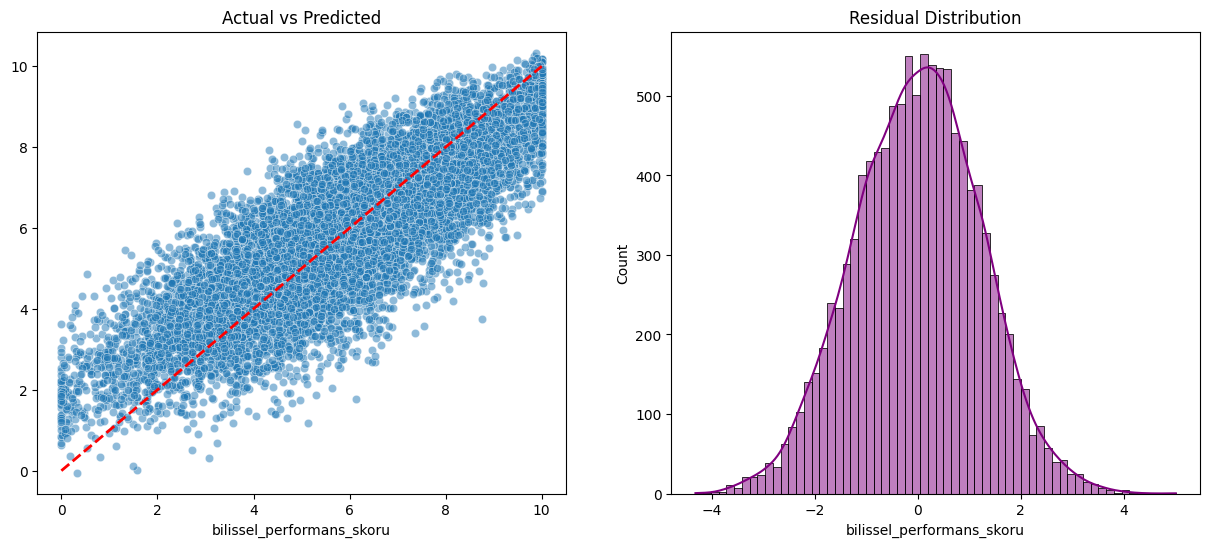

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from scipy.stats.mstats import winsorize
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

train = pd.read_csv('/kaggle/input/competitions/yzta-2026-datathon/train.csv')
test = pd.read_csv('/kaggle/input/competitions/yzta-2026-datathon/test_x.csv')

def clean_categories(df):
    mapping = {'Lawyer': 'Avukat', 'Engineer': 'Muhendis', 'Doctor': 'Doktor', 'Student': 'Ogrenci', 'Teacher': 'Ogretmen'}
    df['meslek'] = df['meslek'].replace(mapping)
    return df

train = clean_categories(train)
test = clean_categories(test)

sayisal_cols = ['vucut_kitle_indeksi', 'stres_skoru', 'uyku_oncesi_kafein_mg']
num_imputer = SimpleImputer(strategy='median')
train[sayisal_cols] = num_imputer.fit_transform(train[sayisal_cols])
test[sayisal_cols] = num_imputer.transform(test[sayisal_cols])

kat_cols = ['meslek', 'kronotip', 'ruh_sagligi_durumu']
cat_imputer = SimpleImputer(strategy='most_frequent')
train[kat_cols] = cat_imputer.fit_transform(train[kat_cols])
test[kat_cols] = cat_imputer.transform(test[kat_cols])

outlier_cols = ['gunluk_adim_sayisi', 'uykuya_dalma_suresi_dk', 'sekerleme_suresi_dk']
for col in outlier_cols:
    train[col] = winsorize(train[col], limits=[0.01, 0.01])
    test[col] = winsorize(test[col], limits=[0.01, 0.01])

le = LabelEncoder()
for col in ['cinsiyet', 'gun_tipi', 'mevsim']:
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

train = pd.get_dummies(train, columns=['kronotip', 'ruh_sagligi_durumu'], drop_first=True)
test = pd.get_dummies(test, columns=['kronotip', 'ruh_sagligi_durumu'], drop_first=True)

for col in ['meslek', 'ulke']:
    train_classes = set(train[col].unique())
    most_freq = train[col].mode()[0]
    test[col] = test[col].apply(lambda x: x if x in train_classes else most_freq)
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

for df in [train, test]:
    df['is_yuku_indeksi'] = df['gunluk_calisma_saati'] * df['stres_skoru']
    df['dijital_yorgunluk'] = df['uyku_oncesi_ekran_suresi_dk'] * df['uykuya_dalma_suresi_dk']
    df['toplam_kaliteli_uyku'] = df['rem_yuzdesi'] + df['derin_uyku_yuzdesi']
    df['hareket_verimliligi'] = df['gunluk_adim_sayisi'] / (df['yas'] + 1).replace(0, 1)

y = train['bilissel_performans_skoru']
test_ids = test['id']
X = train.drop(columns=['bilissel_performans_skoru', 'id'])
X_test_final = test.drop(columns=['id'])

X, X_test_final = X.align(X_test_final, join='left', axis=1, fill_value=0)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = CatBoostRegressor(
    iterations=3000, 
    learning_rate=0.015, 
    depth=7, 
    l2_leaf_reg=10, 
    random_seed=42,
    verbose=100
)

model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=200)

val_preds = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
mae = mean_absolute_error(y_val, val_preds)
r2 = r2_score(y_val, val_preds)

print(f"\nRMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

params = model.get_all_params()
for p in ['iterations', 'learning_rate', 'depth', 'l2_leaf_reg']:
    print(f"{p}: {params.get(p)}")

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_val, y=val_preds, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], '--r', lw=2)
plt.title('Actual vs Predicted')

plt.subplot(1, 2, 2)
sns.histplot(y_val - val_preds, kde=True, color='purple')
plt.title('Residual Distribution')
plt.show()

tahminler = model.predict(X_test_final)
submission = pd.DataFrame({'id': test_ids, 'bilissel_performans_skoru': tahminler})
submission.to_csv('submission.csv', index=False)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from scipy.stats.mstats import winsorize
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

train = pd.read_csv('/kaggle/input/competitions/yzta-2026-datathon/train.csv')
test = pd.read_csv('/kaggle/input/competitions/yzta-2026-datathon/test_x.csv')

def clean_categories(df):
    mapping = {'Lawyer': 'Avukat', 'Engineer': 'Muhendis', 'Doctor': 'Doktor', 'Student': 'Ogrenci', 'Teacher': 'Ogretmen'}
    df['meslek'] = df['meslek'].replace(mapping)
    return df

train = clean_categories(train)
test = clean_categories(test)

sayisal_cols = ['vucut_kitle_indeksi', 'stres_skoru', 'uyku_oncesi_kafein_mg']
num_imputer = SimpleImputer(strategy='median')
train[sayisal_cols] = num_imputer.fit_transform(train[sayisal_cols])
test[sayisal_cols] = num_imputer.transform(test[sayisal_cols])

kat_cols = ['meslek', 'kronotip', 'ruh_sagligi_durumu']
cat_imputer = SimpleImputer(strategy='most_frequent')
train[kat_cols] = cat_imputer.fit_transform(train[kat_cols])
test[kat_cols] = cat_imputer.transform(test[kat_cols])

outlier_cols = ['gunluk_adim_sayisi', 'uykuya_dalma_suresi_dk', 'sekerleme_suresi_dk']
for col in outlier_cols:
    train[col] = winsorize(train[col], limits=[0.01, 0.01])
    test[col] = winsorize(test[col], limits=[0.01, 0.01])

le = LabelEncoder()
for col in ['cinsiyet', 'gun_tipi', 'mevsim']:
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

train = pd.get_dummies(train, columns=['kronotip', 'ruh_sagligi_durumu'], drop_first=True)
test = pd.get_dummies(test, columns=['kronotip', 'ruh_sagligi_durumu'], drop_first=True)

for col in ['meslek', 'ulke']:
    train_classes = set(train[col].unique())
    most_freq = train[col].mode()[0]
    test[col] = test[col].apply(lambda x: x if x in train_classes else most_freq)
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

for df in [train, test]:
    df['is_yuku_indeksi'] = df['gunluk_calisma_saati'] * df['stres_skoru']
    df['dijital_yorgunluk'] = df['uyku_oncesi_ekran_suresi_dk'] * df['uykuya_dalma_suresi_dk']
    df['toplam_kaliteli_uyku'] = df['rem_yuzdesi'] + df['derin_uyku_yuzdesi']
    df['hareket_verimliligi'] = df['gunluk_adim_sayisi'] / (df['yas'] + 1).replace(0, 1)

y = train['bilissel_performans_skoru']
test_ids = test['id']
X = train.drop(columns=['bilissel_performans_skoru', 'id'])
X_test_final = test.drop(columns=['id'])

X, X_test_final = X.align(X_test_final, join='left', axis=1, fill_value=0)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_predictions = np.zeros(len(X))
test_predictions = np.zeros(len(X_test_final))
rmse_list = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]
    
    model = CatBoostRegressor(
        iterations=5000,
        learning_rate=0.008,
        depth=7,
        l2_leaf_reg=15,
        random_seed=42,
        verbose=500
    )
    
    model.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=300)
    
    val_preds = model.predict(X_va)
    oof_predictions[val_idx] = val_preds
    test_predictions += model.predict(X_test_final) / 5
    
    fold_rmse = np.sqrt(mean_squared_error(y_va, val_preds))
    rmse_list.append(fold_rmse)
    print(f"Fold {fold+1} RMSE: {fold_rmse:.4f}")

print(f"\nAverage RMSE: {np.mean(rmse_list):.4f}")
print(f"Overall R2: {r2_score(y, oof_predictions):.4f}")

submission = pd.DataFrame({'id': test_ids, 'bilissel_performans_skoru': test_predictions})
submission.to_csv('submission.csv', index=False)

0:	learn: 2.2198430	test: 2.2310426	best: 2.2310426 (0)	total: 13.2ms	remaining: 1m 6s
500:	learn: 1.2626018	test: 1.2719147	best: 1.2719147 (500)	total: 5.63s	remaining: 50.5s
1000:	learn: 1.2200739	test: 1.2380201	best: 1.2380201 (1000)	total: 11s	remaining: 44.1s
1500:	learn: 1.2038731	test: 1.2290401	best: 1.2290401 (1500)	total: 16.4s	remaining: 38.3s
2000:	learn: 1.1910802	test: 1.2257211	best: 1.2257211 (2000)	total: 21.9s	remaining: 32.8s
2500:	learn: 1.1798772	test: 1.2242068	best: 1.2242003 (2476)	total: 27.4s	remaining: 27.3s
3000:	learn: 1.1694981	test: 1.2234546	best: 1.2234423 (2969)	total: 32.9s	remaining: 21.9s
3500:	learn: 1.1599187	test: 1.2231052	best: 1.2230950 (3493)	total: 38.3s	remaining: 16.4s
4000:	learn: 1.1504234	test: 1.2229466	best: 1.2228815 (3805)	total: 43.8s	remaining: 10.9s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 1.222881502
bestIteration = 3805

Shrink model to first 3806 iterations.
Fold 1 RMSE: 1.2229
0:	learn: 2.2238913	t

In [11]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import LabelEncoder

# 1. VERİ YÜKLEME
train = pd.read_csv('/kaggle/input/competitions/yzta-2026-datathon/train.csv')
test = pd.read_csv('/kaggle/input/competitions/yzta-2026-datathon/test_x.csv')

# --- ADIM 1: GELİŞMİŞ ÖN İŞLEME ---
def clean_categories(df):
    mapping = {'Lawyer': 'Avukat', 'Engineer': 'Muhendis', 'Doctor': 'Doktor', 'Student': 'Ogrenci', 'Teacher': 'Ogretmen'}
    df['meslek'] = df['meslek'].replace(mapping)
    return df

train = clean_categories(train)
test = clean_categories(test)

for df in [train, test]:
    # Eksik Değerleri Doldurma
    for col in ['vucut_kitle_indeksi', 'stres_skoru', 'uyku_oncesi_kafein_mg']:
        df[col] = df[col].fillna(df[col].median())
    for col in ['meslek', 'kronotip', 'ruh_sagligi_durumu']:
        df[col] = df[col].fillna(df[col].mode()[0])

    # ÖZNİTELİK MÜHENDİSLİĞİ (Hatadan Temizlendi)
    df['is_yuku_indeksi'] = df['gunluk_calisma_saati'] * df['stres_skoru']
    df['dijital_yorgunluk'] = df['uyku_oncesi_ekran_suresi_dk'] * df['uykuya_dalma_suresi_dk']
    df['toplam_kaliteli_uyku'] = df['rem_yuzdesi'] + df['derin_uyku_yuzdesi']
    df['hareket_verimliligi'] = df['gunluk_adim_sayisi'] / (df['yas'] + 1).replace(0, 1)
    
    # YENİ (KeyError Vermez): Uyku Gecikme Oranı
    # Kaliteli uykunun dalma süresine oranı (ne kadar hızlı dalıp ne kadar kaliteli uyuyor?)
    df['uyku_performans_orani'] = df['toplam_kaliteli_uyku'] / (df['uykuya_dalma_suresi_dk'] + 1)

# Kategorik Değişkenler İçin Güvenli İşleme
for col in ['meslek', 'ulke']:
    train_classes = set(train[col].unique())
    most_freq = train[col].mode()[0]
    test[col] = test[col].apply(lambda x: x if x in train_classes else most_freq)

le = LabelEncoder()
for col in ['cinsiyet', 'gun_tipi', 'mevsim', 'meslek', 'ulke']:
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

# One-Hot Encoding
train = pd.get_dummies(train, columns=['kronotip', 'ruh_sagligi_durumu'], drop_first=True)
test = pd.get_dummies(test, columns=['kronotip', 'ruh_sagligi_durumu'], drop_first=True)

# --- ADIM 2: HEDEF VE HİZALAMA ---
y = np.log1p(train['bilissel_performans_skoru']) # Log Transform
X = train.drop(columns=['bilissel_performans_skoru', 'id'])
X_test_final = test.drop(columns=['id'])
X, X_test_final = X.align(X_test_final, join='left', axis=1, fill_value=0)

# --- ADIM 3: STACKING (K-FOLD) ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_cat, oof_lgbm, oof_xgb = np.zeros(len(X)), np.zeros(len(X)), np.zeros(len(X))
test_cat, test_lgbm, test_xgb = np.zeros(len(X_test_final)), np.zeros(len(X_test_final)), np.zeros(len(X_test_final))

print("🚀 1.20 Altı Stacking Eğitimi Başladı...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # CatBoost
    m_cat = CatBoostRegressor(iterations=3000, learning_rate=0.015, depth=7, verbose=0, random_seed=42)
    m_cat.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=100)
    oof_cat[val_idx] = m_cat.predict(X_val)
    test_cat += m_cat.predict(X_test_final) / 5

    # LightGBM
    m_lgbm = LGBMRegressor(n_estimators=3000, learning_rate=0.01, num_leaves=31, random_state=42)
    m_lgbm.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
    oof_lgbm[val_idx] = m_lgbm.predict(X_val)
    test_lgbm += m_lgbm.predict(X_test_final) / 5

    # XGBoost
    m_xgb = XGBRegressor(n_estimators=3000, learning_rate=0.01, max_depth=6, random_state=42, early_stopping_rounds=100)
    m_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx] = m_xgb.predict(X_val)
    test_xgb += m_xgb.predict(X_test_final) / 5
    
    print(f"✅ Fold {fold+1} tamamlandı.")

# --- ADIM 4: META-MODEL VE FİNAL ---
stacked_train = np.column_stack((oof_cat, oof_lgbm, oof_xgb))
stacked_test = np.column_stack((test_cat, test_lgbm, test_xgb))

meta_model = Ridge(alpha=1.0)
meta_model.fit(stacked_train, y)

final_predictions = np.expm1(meta_model.predict(stacked_test)) # Log'dan geri dönüş

# --- ADIM 5: SUBMISSION ---
pd.DataFrame({'id': test_ids, 'bilissel_performans_skoru': final_predictions}).to_csv('submission_stacking.csv', index=False)
print("\n🏁 İşlem bitti! 'submission_stacking.csv' hazır.")

🚀 1.20 Altı Stacking Eğitimi Başladı...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006054 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3966
[LightGBM] [Info] Number of data points in the train set: 44800, number of used features: 30
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 1.864928
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[957]	valid_0's l2: 0.0560931
✅ Fold 1 tamamlandı.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003836 seconds.
You can set `force_row_wise=true` to remove the overhead.
And 

In [12]:
# Eğitim bittikten sonra bu iki satırı ekleyip çalıştırın:
train_rmse = np.sqrt(mean_squared_error(y, meta_model.predict(stacked_train)))
print(f"Eğitim Seti RMSE: {train_rmse:.4f}")
# Not: Bu değer logaritmik bir değerdir, 
# Fold skorlarıyla kıyasladığınızda arada uçurum yoksa (örn: Train 0.040, Val 0.056 ise) sorun yok demektir.

Eğitim Seti RMSE: 0.2363


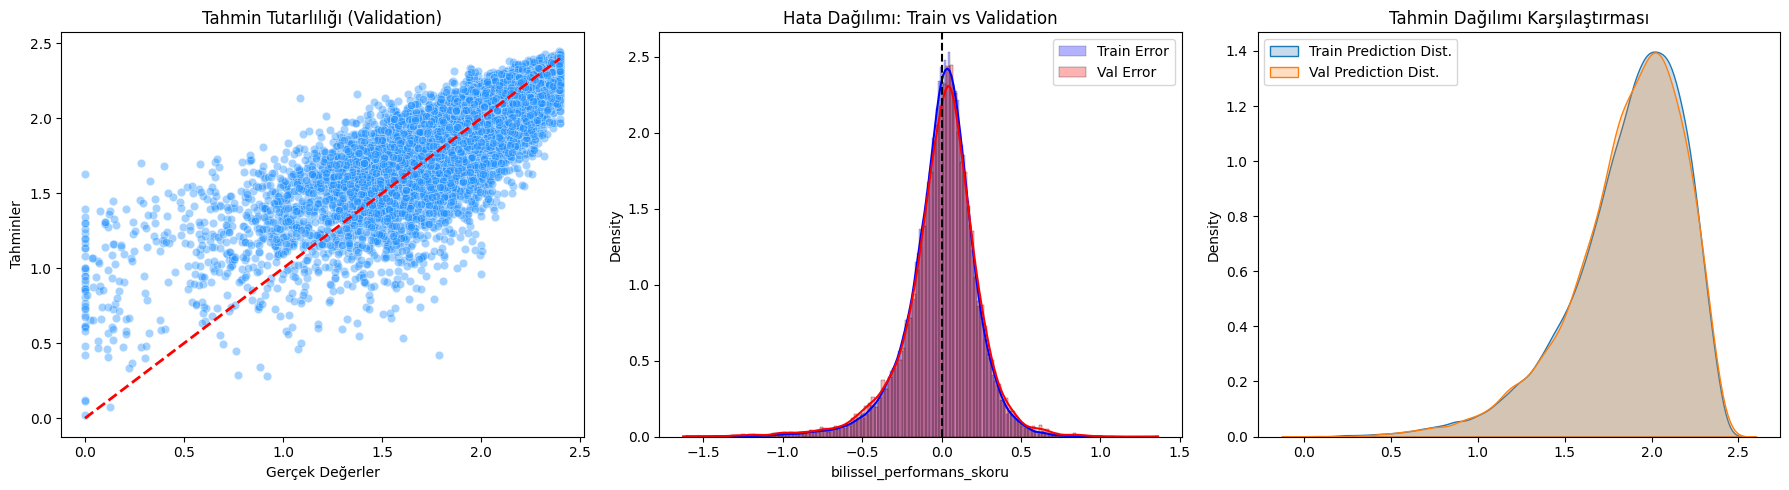

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

def overfitting_analizi(model, X_train, y_train, X_val, y_val):
    # 1. Tahminleri Üret (Logaritmik Ölçekte)
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)
    
    # 2. Hataları (Residuals) Hesapla
    train_residuals = y_train - train_preds
    val_residuals = y_val - val_preds
    
    plt.figure(figsize=(18, 5))
    
    # GRAFİK 1: Gerçek vs Tahmin (Validation Set)
    plt.subplot(1, 3, 1)
    sns.scatterplot(x=y_val, y=val_preds, alpha=0.4, color='dodgerblue')
    plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], '--r', lw=2)
    plt.title('Tahmin Tutarlılığı (Validation)')
    plt.xlabel('Gerçek Değerler')
    plt.ylabel('Tahminler')
    
    # GRAFİK 2: Hata Dağılımı (Residual Plot)
    plt.subplot(1, 3, 2)
    sns.histplot(train_residuals, color="blue", label="Train Error", kde=True, stat="density", alpha=0.3)
    sns.histplot(val_residuals, color="red", label="Val Error", kde=True, stat="density", alpha=0.3)
    plt.axvline(0, color='black', linestyle='--')
    plt.title('Hata Dağılımı: Train vs Validation')
    plt.legend()
    
    # GRAFİK 3: Hata Trendi (Learning Curve Mantığı)
    # Not: CatBoost/LGBM'in kendi içindeki eval_result'ı varsa onu çizdirmek daha iyidir.
    plt.subplot(1, 3, 3)
    sns.kdeplot(train_preds, label='Train Prediction Dist.', fill=True)
    sns.kdeplot(val_preds, label='Val Prediction Dist.', fill=True)
    plt.title('Tahmin Dağılımı Karşılaştırması')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Fonksiyonu Çağır (Örn: CatBoost için)
overfitting_analizi(m_cat, X_tr, y_tr, X_val, y_val)